#**COVID-19 Detection from Chest X-rays using CNN**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
dataset_path= "/content/drive/MyDrive/x_ray_covid19_cnn_project/Covid19-dataset"

In [ ]:
train_path="/content/drive/MyDrive/x_ray_covid19_cnn_project/Covid19-dataset/train"
test_path="/content/drive/MyDrive/x_ray_covid19_cnn_project/Covid19-dataset/test"

print("Train_Path",train_path)
print("Test_Path",test_path)

Train_Path /content/drive/MyDrive/x_ray_covid19_cnn_project/Covid19-dataset/train
Test_Path /content/drive/MyDrive/x_ray_covid19_cnn_project/Covid19-dataset/test


## **1. Data Loading and Exploration**

•	**Import necessary libraries (os, cv2, matplotlib, tensorflow, keras etc.)**

In [ ]:
import os
import numpy as np
import pandas as pd

import cv2
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.model_selection import train_test_split

**•	Load images from different folders and label them**

In [ ]:
print("Train_class")
print(os.listdir(train_path))
print("Test_class")
print(os.listdir(test_path))

Train_class
['Covid', 'Normal', 'Viral Pneumonia']
Test_class
['Covid', 'Normal', 'Viral Pneumonia']


1.**Print datasize per class**



In [ ]:
# train data
for category in os.listdir(train_path):
  category_path=os.path.join(train_path,category)

  if os.path.isdir(category_path):
    num_images=len(os.listdir(category_path))
    print(f"{category} :{num_images},images")

Covid :111,images
Normal :70,images
Viral Pneumonia :70,images


In [ ]:
#Test Data
for category in os.listdir(test_path):
  category_path=os.path.join(test_path,category)

  if os.path.isdir(category_path):
    num_images=len(os.listdir(category_path))
    print(f"{category}:{num_images} images")

Covid:26 images
Normal:20 images
Viral Pneumonia:20 images


**Load Images and Assign Labels**




In [ ]:

X=[]
Y=[]
img_size=224
categories=os.listdir(train_path)
label_map={}

for i ,category in enumerate(categories):
  label_map[category]=i
print(label_map)

{'Covid': 0, 'Normal': 1, 'Viral Pneumonia': 2}


In [ ]:
for category in categories:
  folder_path=os.path.join(train_path,category)
  label=label_map[category]

  for img_name in os.listdir(folder_path):
    img_path=os.path.join(folder_path,img_name)

    try:
      img=cv2.imread(img_path)

      # convert bgr to rgb
      img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

      # resize image
      img=cv2.resize(img,(img_size,img_size))

      # append
      X.append(img)
      Y.append(label)

    except Exception as e:
      ("Error loading image",img_path)



In [ ]:
# lets convert the image and labels to array first so that we have a issue later on
X=np.array(X)
Y=np.array(Y)

print(X.shape)
print(Y.shape)

(251, 224, 224, 3)
(251,)


In [ ]:
#normalization

X=X/255.0

In [ ]:
# Display sample images from each class

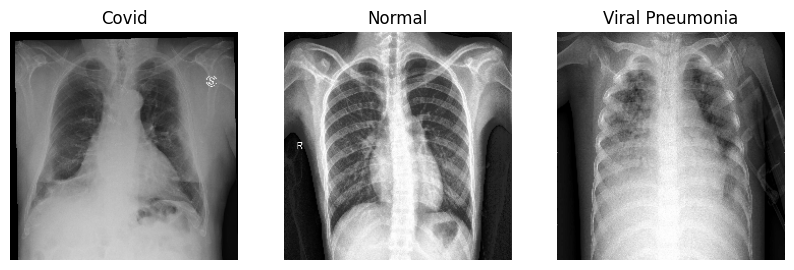

In [ ]:
plt.figure(figsize=(10,10))

for i,category in enumerate(categories):
  folder=os.path.join(train_path,category)
  img_name=os.listdir(folder)[0]
  img_path=os.path.join(folder,img_name)

  img=cv2.imread(img_path)
  img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
  img=cv2.resize(img,(img_size,img_size))

  plt.subplot(1,len(categories),i+1)
  plt.title(category)
  plt.imshow(img)
  plt.axis("off")
plt.show()

# **Visualize the class distribution**

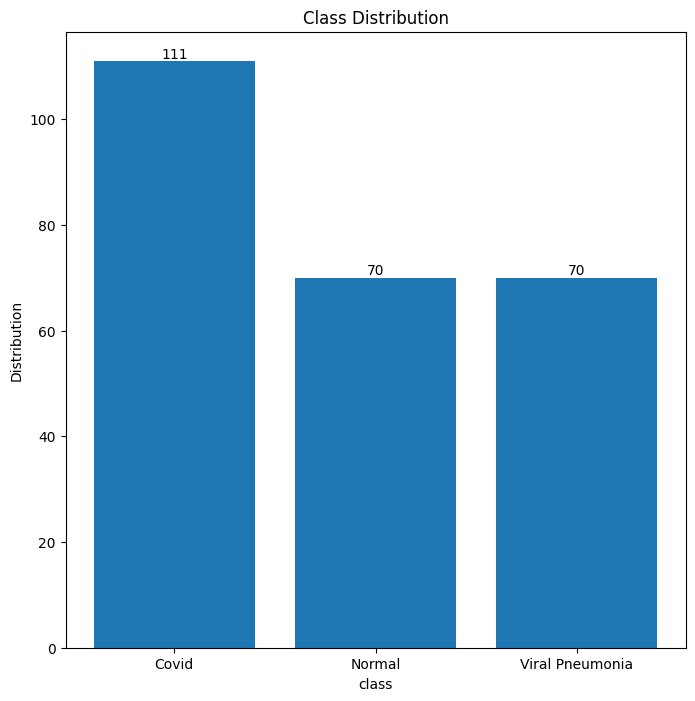

In [ ]:
class_counts=[]
for category in categories:
  folder_path=os.path.join(train_path,category)

  class_counts.append(len(os.listdir(folder_path)))

plt.figure(figsize=(8,8))
ax=plt.bar(categories,class_counts)

plt.bar_label(ax)
plt.title("Class Distribution")
plt.xlabel("class")
plt.ylabel("Distribution")
plt.show()

1. Normal X-rays appear relatively clear.

2. Covid X-rays show cloudy white regions.

3. Viral Pneumonia images show lung opacities.

4. Dataset appears reasonably balanced.

## **4.  1. CNN Model Building- BASIC CNN MODEL BUIDING**

In [ ]:
import sklearn
from sklearn.model_selection import train_test_split

In [ ]:
X_train,X_val,Y_train,Y_val= train_test_split(X,Y,test_size=0.2,random_state=42,stratify=Y)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.callbacks import ModelCheckpoint



In [ ]:
model=Sequential()

# layer 1
model.add(Conv2D(filters=32,kernel_size=(3,3),activation='relu',input_shape=(224,224,3)))

# max pool layer
model.add(MaxPooling2D(pool_size=(2,2)))

#layer 2
model.add(Conv2D(filters=64,kernel_size=(3,3),activation='relu'))

# max_pool_layer
model.add(MaxPooling2D(pool_size=(2,2)))

#layer 3
model.add(Conv2D(filters=128, kernel_size=(3,3), activation='relu'))
MaxPooling2D((2,2))

# add flattening layer
model.add(GlobalAveragePooling2D())

# Dense layer 1
model.add(Dense(units=128,activation='relu'))

#Dropout
model.add(Dropout(0.5))

#Dense layer 2
model.add(Dense(units=64,activation='relu'))

# Output layer
model.add(Dense(units=3,activation='softmax'))


#model summery
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,211 (461.76 KB)

 Trainable params: 118,211 (461.76 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [ ]:
#model check point
checkpoint_model1_basic=ModelCheckpoint(filepath="/content/drive/MyDrive/x_ray_covid19_cnn_project/best_model1_cnn.keras",
                                        monitor='val_accuracy',save_best_only=True,mode='max', verbose=1)
# Train Model
history=model.fit(X_train,Y_train,validation_data=(X_val,Y_val),epochs=50,batch_size=32,callbacks=[checkpoint_model1_basic])

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 514ms/step - accuracy: 0.4262 - loss: 1.0870
Epoch 1: val_accuracy improved from None to 0.45098, saving model to /content/drive/MyDrive/x_ray_covid19_cnn_project/best_model1_cnn.keras

Epoch 1: finished saving model to /content/drive/MyDrive/x_ray_covid19_cnn_project/best_model1_cnn.keras
7/7 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.4300 - loss: 1.0829 - val_accuracy: 0.4510 - val_loss: 1.0619
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.4737 - loss: 1.0792
Epoch 2: val_accuracy did not improve from 0.45098
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.4400 - loss: 1.0950 - val_accuracy: 0.4510 - val_loss: 1.0606
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.4504 - loss: 1.0816
Epoch 3: val_accuracy did not improve from 0.45098
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.4400 - loss: 1.0808 - val_accuracy: 0.4510 - val_loss: 1.0646
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 

### **EVALUATION OF THE Basic Model 1**

In [ ]:
# First Conver the train data into X_test and Y_test and Evaluate(X_test=images,Y_test=labels)

X_test=[]
Y_test=[]
for category in categories:
  folder_path=os.path.join(test_path,category)
  label=label_map[category]

  for img_name in  os.listdir(folder_path):
    img_path=os.path.join(folder_path,img_name)

    try:
      img=cv2.imread(img_path)
      img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
      img=cv2.resize(img,(img_size,img_size))

      X_test.append(img)
      Y_test.append(label)

    except Exception as e:
      print("Error loading image",img_path)



In [ ]:
X_test=np.array(X_test)
Y_test=np.array(Y_test)

In [ ]:
X_test = X_test / 255.0

In [ ]:
# Evaluate Test Accuracy
test_loss,test_accuracy=model.evaluate(X_test,Y_test,verbose=1)

print("Test_loss:",test_loss)
print("Test_accuracy:",test_accuracy)


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 348ms/step - accuracy: 0.6667 - loss: 0.5629
Test_loss: 0.5628545880317688
Test_accuracy: 0.6666666865348816


In [ ]:
print(history.history['accuracy'][-1])
print(history.history['val_accuracy'][-1])

0.7200000286102295
0.8627451062202454


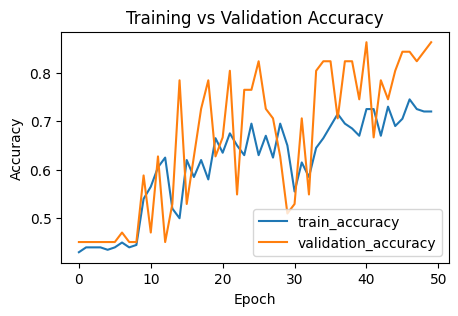

In [ ]:
# lets see training vs valiadion accuracy graph

import matplotlib.pyplot as plt
plt.figure(figsize=(5,3))

plt.plot(history.history['accuracy'],label='train_accuracy')
plt.plot(history.history['val_accuracy'],label='validation_accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

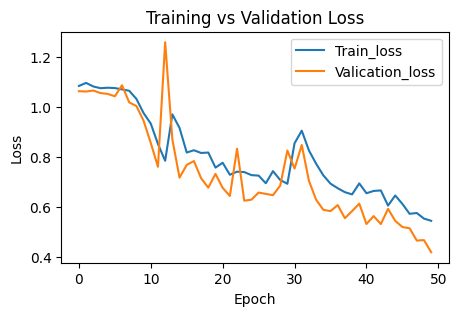

In [ ]:
# Training vs Validation loss graph
plt.figure(figsize=(5,3))

plt.plot(history.history["loss"],label='Train_loss')
plt.plot(history.history["val_loss"],label='Valication_loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:
# generating the classification report and confusion matrix by prediciton on test set

In [ ]:
# class


y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
print("Classification_Report")
print(classification_report(Y_test, y_pred_classes, target_names=categories))

print("__"*50)

print("Confusion_Matrix")
cm=confusion_matrix(Y_test, y_pred_classes)
print(cm)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 173ms/step
Classification_Report
                 precision    recall  f1-score   support

          Covid       0.96      0.96      0.96        26
         Normal       0.47      0.40      0.43        20
Viral Pneumonia       0.48      0.55      0.51        20

       accuracy                           0.67        66
      macro avg       0.64      0.64      0.64        66
   weighted avg       0.67      0.67      0.66        66

____________________________________________________________________________________________________
Confusion_Matrix
[[25  1  0]
 [ 0  8 12]
 [ 1  8 11]]


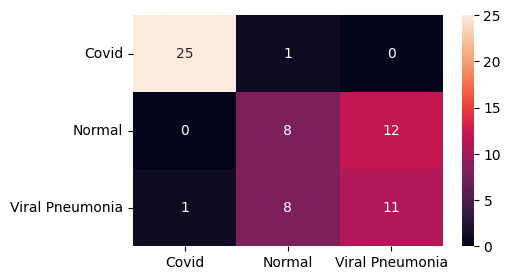

In [ ]:
6# confusion matrix visualization
plt.figure(figsize=(5,3))
import seaborn as sns
sns.heatmap(cm,annot=True,fmt='d',xticklabels=categories,yticklabels=categories)
plt.show()

In [ ]:
# Calculating ROC-AUC CURVE

from tensorflow.keras.utils import to_categorical
y_test_bin=to_categorical(Y_test,num_classes=3)

from sklearn.metrics import roc_auc_score
roc_auc=roc_auc_score(y_test_bin,y_pred,multi_class='ovr')
print("ROC_AUC_Score:",roc_auc)


ROC_AUC_Score: 0.8493171683389075


## **Model 2: Transfer Learning**

In [ ]:
from tensorflow.keras.applications import VGG16

In [ ]:
base_model=VGG16(weights='imagenet',include_top= False,input_shape=(224,224,3))
for layers in base_model.layers:
  layers.trainable=False

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# building the model

#Sequential
model_vgg=Sequential()

# Adding Base model
model_vgg.add(base_model)

# Global Average Pooling
model_vgg.add(GlobalAveragePooling2D())

# Dense Layer 1
model_vgg.add(Dense(units=128,activation='relu'))

#Dropout Layer 1
model_vgg.add(Dropout(0.5))

#Dense Layer 2
model_vgg.add(Dense(units=64,activation='relu'))

#Output Layer
model_vgg.add(Dense(units=3,activation='softmax'))

#Model Summary
model_vgg.summary()




Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,788,803 (56.41 MB)

 Trainable params: 74,115 (289.51 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
# Model Compilation
model_vgg.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [ ]:
#model checkpoint 2
model_checkpoint2_vgg16=ModelCheckpoint( filepath="/content/drive/MyDrive/x_ray_covid19_cnn_project/best_model2_vgg16.keras",
                                        monitor='val_accuracy',save_best_only=True,mode='max',verbose=1)
#Model Training
history_vgg=model_vgg.fit(X_train,Y_train,validation_data=(X_val,Y_val),epochs=40,batch_size=32,callbacks=[model_checkpoint2_vgg16])

Epoch 1/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3247 - loss: 1.2672   
Epoch 1: val_accuracy improved from None to 0.45098, saving model to /content/drive/MyDrive/x_ray_covid19_cnn_project/best_model2_vgg16.keras

Epoch 1: finished saving model to /content/drive/MyDrive/x_ray_covid19_cnn_project/best_model2_vgg16.keras
7/7 ━━━━━━━━━━━━━━━━━━━━ 41s 4s/step - accuracy: 0.3600 - loss: 1.2114 - val_accuracy: 0.4510 - val_loss: 1.0397
Epoch 2/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.4170 - loss: 1.0894
Epoch 2: val_accuracy improved from 0.45098 to 0.68627, saving model to /content/drive/MyDrive/x_ray_covid19_cnn_project/best_model2_vgg16.keras

Epoch 2: finished saving model to /content/drive/MyDrive/x_ray_covid19_cnn_project/best_model2_vgg16.keras
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 291ms/step - accuracy: 0.4400 - loss: 1.0719 - val_accuracy: 0.6863 - val_loss: 0.9974
Epoch 3/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.4965 - loss: 1.0230
Epoch 3: val_accu

In [ ]:
# Lest Fine Tune last few layers of Covid Data set A per the requirement

for layer in base_model.layers[-4:]:
  layer.trainable=True

In [ ]:
from tensorflow.keras.optimizers import Adam
model_vgg.compile(optimizer=Adam(learning_rate=0.00001),loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [ ]:


history_vgg_finetune = model_vgg.fit(
    X_train,
    Y_train,
    validation_data=(X_val, Y_val),
    epochs=15,
    batch_size=32
)

Epoch 1/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.9300 - loss: 0.1898 - val_accuracy: 1.0000 - val_loss: 0.0481
Epoch 2/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 267ms/step - accuracy: 0.9200 - loss: 0.1729 - val_accuracy: 1.0000 - val_loss: 0.0379
Epoch 3/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 266ms/step - accuracy: 0.9600 - loss: 0.1528 - val_accuracy: 1.0000 - val_loss: 0.0369
Epoch 4/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 270ms/step - accuracy: 0.9750 - loss: 0.1024 - val_accuracy: 1.0000 - val_loss: 0.0561
Epoch 5/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 272ms/step - accuracy: 0.9550 - loss: 0.1196 - val_accuracy: 1.0000 - val_loss: 0.0247
Epoch 6/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 279ms/step - accuracy: 0.9800 - loss: 0.0832 - val_accuracy: 1.0000 - val_loss: 0.0285
Epoch 7/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 282ms/step - accuracy: 0.9900 - loss: 0.0791 - val_accuracy: 1.0000 - val_loss: 0.0320
Epoch 8/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 287ms/step - accuracy: 0.9800 - loss: 0.0991 - val_accuracy: 1.0000 - val_loss: 0

In [ ]:
test_loss_vgg, test_accuracy_vgg = model_vgg.evaluate(
    X_test,
    Y_test
)

print(f"VGG16 Test Loss: {test_loss_vgg:.4f}")
print(f"VGG16 Test Accuracy: {test_accuracy_vgg:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.9848 - loss: 0.0888
VGG16 Test Loss: 0.0888
VGG16 Test Accuracy: 0.9848


In [ ]:
# confusion matrix

y_pred_vgg=model_vgg.predict(X_test)
y_pred_classes_vgg=np.argmax(y_pred_vgg,axis=1)

cm_vgg=confusion_matrix(Y_test,y_pred_classes_vgg)

print(cm_vgg)

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 412ms/step
[[26  0  0]
 [ 0 19  1]
 [ 0  0 20]]


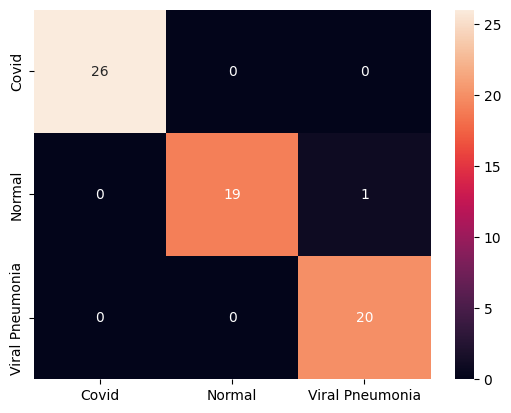

In [ ]:
# Confusion Matrix Visualization
sns.heatmap(cm_vgg,annot=True,fmt='d',xticklabels=categories,yticklabels=categories)
plt.show()

In [ ]:
## classification report
report_vgg=classification_report(Y_test,y_pred_classes_vgg,target_names=categories)
print(report_vgg)

                 precision    recall  f1-score   support

          Covid       1.00      1.00      1.00        26
         Normal       1.00      0.95      0.97        20
Viral Pneumonia       0.95      1.00      0.98        20

       accuracy                           0.98        66
      macro avg       0.98      0.98      0.98        66
   weighted avg       0.99      0.98      0.98        66



In [ ]:
roc_auc = roc_auc_score(
    Y_test,
    y_pred_vgg,
    multi_class='ovr',   # One-vs-Rest
    average='macro'      # Average across classes
)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.9971014492753624


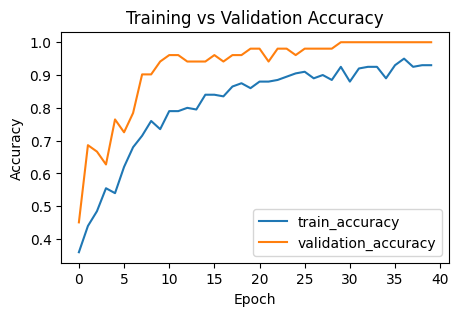

In [ ]:
# lets see training vs valiadion accuracy graph  of vgg
import matplotlib.pyplot as plt
plt.figure(figsize=(5,3))

plt.plot(history_vgg.history['accuracy'],label='train_accuracy')
plt.plot(history_vgg.history['val_accuracy'],label='validation_accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

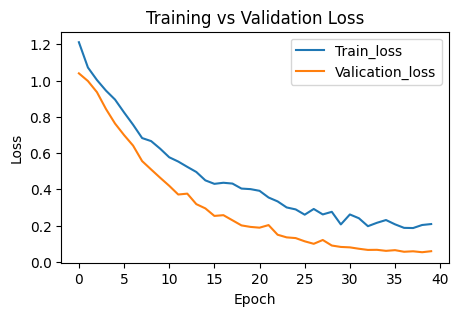

In [ ]:
#Training vs Validation loss graph
plt.figure(figsize=(5,3))

plt.plot(history_vgg.history["loss"],label='Train_loss')
plt.plot(history_vgg.history["val_loss"],label='Valication_loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

## **3.Model 3: Transfer Learning + Data Augmentation**

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
# DATA AUGUMENTATION PIPELINE

train_datagen= ImageDataGenerator(rescale=1./255,rotation_range=20,width_shift_range=0.1,height_shift_range=0.1,zoom_range=0.2,validation_split=0.2)

val_datagen=ImageDataGenerator(rescale=1./255,validation_split=0.2)

test_datagen=ImageDataGenerator(rescale=1./255)

In [ ]:
# GENERATORS
#Train Generator
train_generator=train_datagen.flow_from_directory(train_path,target_size=(224,224),batch_size=32,class_mode='categorical',subset='training')
#Validation_Generator
validation_generator=val_datagen.flow_from_directory(train_path,target_size=(224,224),batch_size=32,class_mode='categorical',subset='validation')

#Test Generator
test_generator=test_datagen.flow_from_directory(test_path,target_size=(224,224),batch_size=32,class_mode='categorical',shuffle=False)

Found 201 images belonging to 3 classes.
Found 50 images belonging to 3 classes.
Found 66 images belonging to 3 classes.


In [ ]:
from tensorflow.keras.applications import VGG16
base_model1=VGG16(weights='imagenet',include_top=False,input_shape=(224,224,3))

for layer in base_model1.layers:
  layer.trainable=False

In [ ]:
# model Building

model_aug=Sequential()

#base model

model_aug.add(base_model1)

#flatten
model_aug.add(GlobalAveragePooling2D())

#Dense Layer 1
model_aug.add(Dense(units=128,activation='relu'))

#Dropout Layer
model_aug.add(Dropout(0.5))

#Dense Layer 2
model_aug.add(Dense(units=64,activation='relu'))

#Output Layer
model_aug.add(Dense(units=3,activation='softmax'))

#summary
model_aug.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,788,803 (56.41 MB)

 Trainable params: 74,115 (289.51 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
model_aug.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [ ]:
#ModelCheckpoint3
ModelCheckpoint3_aug=ModelCheckpoint(filepath="/content/drive/MyDrive/x_ray_covid19_cnn_project/best_model3_aug.keras",
                                     monitor='val_accuracy',save_best_only=True,mode='max',verbose=1)
#Training
history_aug=model_aug.fit(train_generator,validation_data=validation_generator,epochs=30,callbacks=[ModelCheckpoint3_aug])

Epoch 1/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3115 - loss: 1.2085
Epoch 1: val_accuracy improved from None to 0.50000, saving model to /content/drive/MyDrive/x_ray_covid19_cnn_project/best_model3_aug.keras

Epoch 1: finished saving model to /content/drive/MyDrive/x_ray_covid19_cnn_project/best_model3_aug.keras
7/7 ━━━━━━━━━━━━━━━━━━━━ 38s 6s/step - accuracy: 0.3980 - loss: 1.1556 - val_accuracy: 0.5000 - val_loss: 1.0180
Epoch 2/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 829ms/step - accuracy: 0.4408 - loss: 1.0567
Epoch 2: val_accuracy improved from 0.50000 to 0.66000, saving model to /content/drive/MyDrive/x_ray_covid19_cnn_project/best_model3_aug.keras

Epoch 2: finished saving model to /content/drive/MyDrive/x_ray_covid19_cnn_project/best_model3_aug.keras
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.4378 - loss: 1.0446 - val_accuracy: 0.6600 - val_loss: 0.9660
Epoch 3/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5792 - loss: 0.9413
Epoch 3: val_accuracy did not impr

In [ ]:
#Fine Tuning last layers
for layer in base_model1.layers[-4:]:
  layer.trainable=True

In [ ]:
# recompile
model_aug.compile(optimizer=Adam(learning_rate=0.0001),loss='categorical_crossentropy',metrics=['accuracy'])

In [ ]:
history_aug_finetune=model_aug.fit(train_generator,validation_data=validation_generator,epochs=15)

Epoch 1/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.6567 - loss: 0.9353 - val_accuracy: 0.6600 - val_loss: 0.6721
Epoch 2/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.7910 - loss: 0.5315 - val_accuracy: 0.7600 - val_loss: 0.5920
Epoch 3/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.8408 - loss: 0.3735 - val_accuracy: 0.8600 - val_loss: 0.3725
Epoch 4/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.9055 - loss: 0.3027 - val_accuracy: 0.7600 - val_loss: 0.6040
Epoch 5/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.9104 - loss: 0.2224 - val_accuracy: 0.9000 - val_loss: 0.3084
Epoch 6/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.9254 - loss: 0.1968 - val_accuracy: 0.8200 - val_loss: 0.5117
Epoch 7/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.9502 - loss: 0.1863 - val_accuracy: 0.8400 - val_loss: 0.4263
Epoch 8/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.9254 - loss: 0.2296 - val_accuracy: 0.8800 - val_loss: 0.4412
Epoch 9/15
7

In [ ]:
#Evaluate

#Confusion Matrix

y_pred_aug=model_aug.predict(test_generator)
y_pred_classes=np.argmax(y_pred_aug,axis=1)
cm=confusion_matrix(test_generator.classes,y_pred_classes)
print(cm)

2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 395ms/step
[[26  0  0]
 [ 0 20  0]
 [ 0  3 17]]


In [ ]:
# Classification Report
print(classification_report(test_generator.classes,y_pred_classes,target_names=categories))

                 precision    recall  f1-score   support

          Covid       1.00      1.00      1.00        26
         Normal       0.87      1.00      0.93        20
Viral Pneumonia       1.00      0.85      0.92        20

       accuracy                           0.95        66
      macro avg       0.96      0.95      0.95        66
   weighted avg       0.96      0.95      0.95        66



In [ ]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(
    Y_test,
    y_pred_aug,
    multi_class='ovr',   # One-vs-Rest
    average='macro'      # Average across classes
)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.9978260869565218


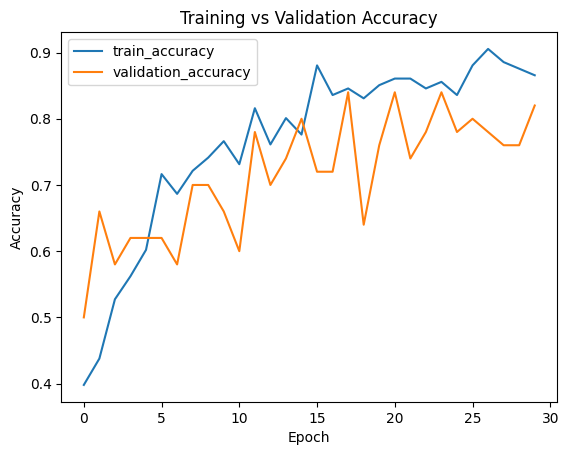

In [ ]:
# Training vs Validation Accuracy
plt.plot(history_aug.history['accuracy'],label='train_accuracy')
plt.plot(history_aug.history['val_accuracy'],label='validation_accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

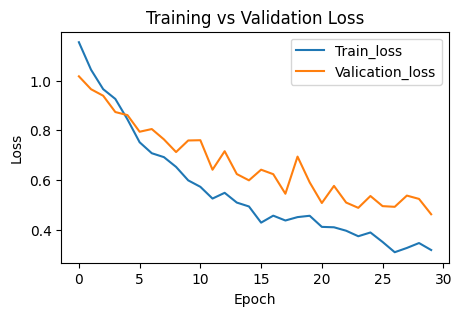

In [ ]:
#Training vs Validation loss graph
plt.figure(figsize=(5,3))

plt.plot(history_aug.history["loss"],label='Train_loss')
plt.plot(history_aug.history["val_loss"],label='Valication_loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

**Model 4 (Resnet 50)  : Using techniques like:
•	Early stopping
•	Hyperparameter tuning (number of filters, dropout rate, optimizer etc.)**


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

class_counts = Counter(Y)

print(class_counts)

Counter({np.int64(0): 111, np.int64(1): 70, np.int64(2): 70})


In [ ]:
# class weights

from sklearn.utils.class_weight import compute_class_weight
class_weights=compute_class_weight(class_weight='balanced',classes=np.unique(Y_train),y=Y_train)
class_weights=dict(enumerate(class_weights))

In [ ]:
print(type(class_weights))
print(class_weights)

<class 'dict'>
{0: np.float64(0.7575757575757576), 1: np.float64(1.1904761904761905), 2: np.float64(1.1904761904761905)}


In [ ]:
# Loading RESNET50
from tensorflow.keras.applications import ResNet50
base_model2=ResNet50(weights='imagenet',include_top=False,input_shape=(224,224,3))

for layer in base_model2.layers:
  layer.trainable=False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [ ]:
# model_building
from tensorflow.keras.models import Sequential

model_resnet=Sequential()

#Pretrained Model addition
model_resnet.add(base_model2)

#GlobalAverage Pooling

model_resnet.add(GlobalAveragePooling2D())

#DensE Layer 1
model_resnet.add(Dense(256,activation='relu'))

#Dropout Layer
model_resnet.add(Dropout(0.5))

#Dense Layer 2
model_resnet.add(Dense(128,activation='relu'))

#Dropout Layer
model_resnet.add(Dropout(0.3))

#Output Layer
model_resnet.add(Dense(3,activation='softmax'))



In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
# Model Compile
model_resnet.compile(optimizer=Adam(learning_rate=0.0001),loss='categorical_crossentropy',metrics=['accuracy'])

#Early Stopping
early_stop=EarlyStopping(monitor='val_loss',patience=15,restore_best_weights=True,verbose=1)

#ModelCheckpoint
model_checkpoint_resnet=ModelCheckpoint(  filepath="/content/drive/MyDrive/x_ray_covid19_cnn_project/best_resnet50.keras",
    monitor='val_accuracy',save_best_only=True, mode='max',verbose=1)

In [ ]:
# Train Model
history_resnet=model_resnet.fit(train_generator,validation_data=validation_generator,epochs=50,class_weight=class_weights,callbacks=[model_checkpoint_resnet,early_stop])

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3470 - loss: 2.3814
Epoch 1: val_accuracy improved from None to 0.28000, saving model to /content/drive/MyDrive/x_ray_covid19_cnn_project/best_resnet50.keras

Epoch 1: finished saving model to /content/drive/MyDrive/x_ray_covid19_cnn_project/best_resnet50.keras
7/7 ━━━━━━━━━━━━━━━━━━━━ 48s 5s/step - accuracy: 0.3483 - loss: 2.3895 - val_accuracy: 0.2800 - val_loss: 1.4286
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 862ms/step - accuracy: 0.2910 - loss: 1.5587
Epoch 2: val_accuracy did not improve from 0.28000
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.2886 - loss: 1.4924 - val_accuracy: 0.2800 - val_loss: 1.1011
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 963ms/step - accuracy: 0.4677 - loss: 1.1311
Epoch 3: val_accuracy improved from 0.28000 to 0.46000, saving model to /content/drive/MyDrive/x_ray_covid19_cnn_project/best_resnet50.keras

Epoch 3: finished saving model to /content/drive/MyDrive/x_ray_covid19_cnn_project/best_res

In [ ]:
# Fine tuning
for layer in base_model2.layers[-300:]:
  layer.trainable=True


In [ ]:
for layer in base_model2.layers[-30:]:
    print(layer.name, layer.trainable)

In [ ]:
model_resnet.compile(optimizer=Adam(learning_rate=0.00001),loss="categorical_crossentropy",metrics=['accuracy'])

In [ ]:
# Train ahain
history_finetune_vgg=model_resnet.fit(train_generator,validation_data=validation_generator,epochs=15,class_weight=class_weights,callbacks=[model_checkpoint_resnet,early_stop])

Epoch 1/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6153 - loss: 0.9772
Epoch 1: val_accuracy did not improve from 0.78000
7/7 ━━━━━━━━━━━━━━━━━━━━ 31s 3s/step - accuracy: 0.5920 - loss: 1.0033 - val_accuracy: 0.6200 - val_loss: 0.9187
Epoch 2/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 917ms/step - accuracy: 0.5429 - loss: 1.0043
Epoch 2: val_accuracy did not improve from 0.78000
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.5323 - loss: 1.0147 - val_accuracy: 0.7600 - val_loss: 0.9103
Epoch 3/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5451 - loss: 1.0395
Epoch 3: val_accuracy did not improve from 0.78000
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.5572 - loss: 1.0131 - val_accuracy: 0.7600 - val_loss: 0.9035
Epoch 4/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6075 - loss: 0.9850
Epoch 4: val_accuracy did not improve from 0.78000
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.5771 - loss: 0.9966 - val_accuracy: 0.7600 - val_loss: 0.9059
Epoch 5/15
7/7 ━━━━━

In [ ]:
# Rest net Evaluation
test_loss_resnet,test_accuracy_resnet=model_resnet.evaluate(test_generator)

print("Test_Loss_resnet",test_loss_resnet)
print('Test_accuracy_resnet',test_accuracy_resnet)

3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.7273 - loss: 0.8183
Test_Loss_resnet 0.8183010816574097
Test_accuracy_resnet 0.7272727489471436


In [ ]:
#predictions

y_pred_resnet=model_resnet.predict(test_generator)
y_pred_class_resnet=np.argmax(y_pred_resnet,axis=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 234ms/step


In [ ]:
# classification
from sklearn.metrics import classification_report,confusion_matrix,roc_auc_score
y_true = test_generator.classes
classification_resnet= classification_report(y_true,y_pred_class_resnet)

print(classification_resnet)

              precision    recall  f1-score   support

           0       0.96      0.88      0.92        26
           1       0.58      0.90      0.71        20
           2       0.64      0.35      0.45        20

    accuracy                           0.73        66
   macro avg       0.73      0.71      0.69        66
weighted avg       0.75      0.73      0.71        66



In [ ]:
#confusion matrix
confusion_matrix_resnet=confusion_matrix(y_true,y_pred_class_resnet)
print(confusion_matrix_resnet)

[[23  1  2]
 [ 0 18  2]
 [ 1 12  7]]


In [ ]:
# roc auc score
roc_auc = roc_auc_score(
    Y_test,
   y_pred_resnet,
    multi_class='ovr',   # One-vs-Rest
    average='macro'      # Average across classes
)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.9009615384615385


### **COMPARISION TABLE**

| **Model**                                 | **Test Accuracy (%)** | **F1-Score (Weighted Avg.)** | **ROC-AUC Score** | **Remarks**                                                                      |
| ----------------------------------------- | --------------------- | ---------------------------- | ----------------- | -------------------------------------------------------------------------------- |
| Basic CNN                                 | 66.67%                | 0.66                         | N/A               | Underfitting; poor performance in Normal and Viral Pneumonia classification      |
| VGG16                                     | **98.48%**            | **0.98**                     | 0.9971            | Best overall performance with excellent classification across all classes        |
| VGG16 + Data Augmentation                 | 95.00%                | 0.95                         | **0.9978**        | More robust and generalized model; slight decrease in accuracy compared to VGG16 |
| ResNet50 + Class Weights & Early Stopping | 72.73%                | 0.71                         | 0.9010            | Moderate performance; struggled to classify Viral Pneumonia effectively          |


# **Streamlit code**

In [ ]:
import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image

# Load model
@st.cache_resource
def load_model():
    model = tf.keras.models.load_model("best_model2_vgg16.keras")
    return model

model = load_model()

# Class names
class_names = ['Covid', 'Normal', 'Viral Pneumonia']

st.title("Chest X-Ray Classification")
st.write("Upload an X-ray image to predict the disease.")

uploaded_file = st.file_uploader(
    "Choose an image",
    type=["jpg", "jpeg", "png"]
)

if uploaded_file is not None:

    image = Image.open(uploaded_file).convert('RGB')

    st.image(image, caption="Uploaded Image", use_container_width=True)

    # Preprocessing
    img = image.resize((224, 224))
    img_array = np.array(img)

    img_array = img_array / 255.0

    img_array = np.expand_dims(img_array, axis=0)

    # Prediction
    prediction = model.predict(img_array)

    predicted_class = np.argmax(prediction)

    confidence = np.max(prediction) * 100

    st.subheader("Prediction")

    st.success(
        f"{class_names[predicted_class]}"
    )

    st.write(
        f"Confidence: {confidence:.2f}%"
    )

    st.subheader("Probabilities")

    for cls, prob in zip(class_names, prediction[0]):
        st.write(f"{cls}: {prob*100:.2f}%")